# Project 5 — Liquidity Risk in ETF–Bond Arbitrage: TLT vs US Treasuries

**Goal.** Study the iShares 20+ Year Treasury ETF (**TLT**) against the bonds it holds, measure how far its price dislocates
from fair value, relate the dislocations to liquidity conditions, and build a statistical-arbitrage strategy whose sizing and
entry rules respect liquidity constraints.

**Data.**
* TLT daily bars, 1-minute SIP bars and intraday liquidity features (quoted-spread estimates, dollar volume) from Massive,
  Sep-2021 → Sep-2026;
* CME Treasury futures, 1-minute bars (Databento): **UB** (Ultra T-Bond, deliverable 25+ years, the closest match to TLT's
  duration) and **ZB** (T-Bond, 15–25 years), Sep-2021 → Jun-2025;
* FRED constant-maturity Treasury yields (20y, 30y) for the bond-math part.

The official intraday NAV / daily NAV history isn't in our data sets, so we build two fair-value proxies: a **model NAV** from
the Treasury curve (§2) and a **futures-implied fair value** at synchronised timestamps (§3). The second is what practitioners
actually trade against.

| § | Content |
|---|---|
| 1 | How bond-ETF arbitrage works, and why it breaks in stress |
| 2 | Bond math: TLT as a 20–30y Treasury ladder (duration, convexity, the NAV-timing problem) |
| 3 | Futures-implied fair value and the dislocation series |
| 4 | Liquidity: measuring it, and how it drives dislocations |
| 5 | A stat-arb strategy with liquidity constraints |
| 6 | Strengths, weaknesses, extensions |

## 1. The ETF arbitrage mechanism
* An ETF trades on an exchange, while its **NAV** is the value of the underlying bonds. **Authorised participants (APs)** can
  *create* shares (deliver a bond basket, receive ETF shares) or *redeem* them (the reverse). If TLT trades above NAV by more
  than the cost of buying the bonds and creating, an AP sells TLT and creates, which pushes the premium back into a band.
* The width of that no-arbitrage band is set by **bond-market liquidity**: bid–ask spreads on off-the-run long bonds, balance-sheet
  costs of carrying inventory, and creation/redemption fees. When bond liquidity evaporates (March 2020), the band widens, and
  bond ETFs traded at large *discounts*. The ETF, which trades continuously, was doing the price discovery, while NAV
  reflected stale evaluated bond prices.
* **The NAV-timing trap.** The official NAV uses bond prices struck around 15:00 ET, while TLT closes at 16:00. On a day when
  yields move after 15:00, TLT's closing "premium" is simply the post-15:00 rate move. A naïve premium/discount series mixes
  genuine dislocation with this timing artefact. Futures trade continuously and can be sampled at *exactly* the same minute as
  the ETF, which is why we use them as fair value.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from IPython.display import display

from qdata import load_panel, load_minute_bars, load_intraday_features, fred_rates, treasury_futures_1m

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

tlt_d = load_panel(["TLT"], "2021-09-01", "2026-09-30",
                   columns=("ticker", "close", "adj_close", "ret", "volume", "dividend")).set_index("date")
fr = fred_rates()[["DGS20", "DGS30"]].loc["2021-08-01":].dropna() / 100
print(f"TLT daily: {tlt_d.index[0].date()} → {tlt_d.index[-1].date()}  ({len(tlt_d)} days)")

TLT daily: 2021-09-13 → 2026-09-11  (1255 days)


## 2. Bond math: TLT as a ladder of 20–30y Treasuries
TLT tracks the ICE US Treasury 20+ Year index, roughly the Treasuries with 20–30 years to maturity. We approximate it by an
**equal-weighted constant-maturity ladder** of par bonds with maturities 20, 21, …, 30 years, priced off the CMT curve (linear
in maturity between the 20y and 30y yields). Each day every rung is bought at par at yesterday's yield and revalued at today's,
so its daily total return is
$$r_t=\underbrace{\text{carry}}_{c/252}+\underbrace{\big(P(c,\tau-\tfrac1{252},y_t)-1\big)}_{\approx -D\,\Delta y+\tfrac12 C\,\Delta y^2}.$$
Comparing this model index with TLT's total return shows how much of TLT is pure rate risk, and how noisy a daily NAV-style
comparison is.

In [2]:
def bond_price(c, T, y, f=2):
    """Price per 1 face of a bond paying coupon c (annual, paid f times a year), maturity T years, yield y (same basis)."""
    n = np.maximum(np.round(T * f), 1)
    df = (1 + y / f) ** (-np.arange(1, n + 1))
    return (c / f) * df.sum() + df[-1]


def mod_duration(c, T, y, h=1e-4):
    return -(bond_price(c, T, y + h) - bond_price(c, T, y - h)) / (2 * h * bond_price(c, T, y))


def convexity(c, T, y, h=1e-4):
    return (bond_price(c, T, y + h) - 2 * bond_price(c, T, y) + bond_price(c, T, y - h)) / (h * h * bond_price(c, T, y))


MATS = np.arange(20, 31)
w_ = (MATS - 20) / 10
Ymat = pd.DataFrame(np.outer(1 - w_, fr.DGS20) + np.outer(w_, fr.DGS30), index=MATS, columns=fr.index).T   # yields per rung
ladder_ret = []
for t in range(1, len(Ymat)):
    y0, y1 = Ymat.iloc[t - 1].values, Ymat.iloc[t].values
    dt = (Ymat.index[t] - Ymat.index[t - 1]).days / 365
    r = [bond_price(y0[i], M - dt, y1[i]) - 1 + y0[i] * dt for i, M in enumerate(MATS)]
    ladder_ret.append(np.mean(r))
ladder = pd.Series(ladder_ret, index=Ymat.index[1:], name="ladder")

y_now = Ymat.iloc[-1]
print(f"Ladder at {Ymat.index[-1].date()}: avg yield {y_now.mean():.2%}, mod. duration "
      f"{np.mean([mod_duration(y_now[M], M, y_now[M]) for M in MATS]):.1f}, convexity "
      f"{np.mean([convexity(y_now[M], M, y_now[M]) for M in MATS]):.0f}")

j = pd.concat([tlt_d.ret.rename("TLT"), ladder], axis=1).dropna()
fit = sm.OLS(j.TLT, sm.add_constant(j.ladder)).fit()
j5 = (1 + j).resample("W-FRI").prod() - 1
fit5 = sm.OLS(j5.TLT, sm.add_constant(j5.ladder)).fit()
print(f"daily  TLT = {fit.params.iloc[0]*1e4:.1f}bp + {fit.params.iloc[1]:.3f}·ladder   R² = {fit.rsquared:.3f}   "
      f"tracking error {np.std(fit.resid)*np.sqrt(252):.2%}/yr")
print(f"weekly TLT = {fit5.params.iloc[0]*1e4:.1f}bp + {fit5.params.iloc[1]:.3f}·ladder   R² = {fit5.rsquared:.3f}")

Ladder at 2026-09-24: avg yield 5.50%, mod. duration 13.4, convexity 262
daily  TLT = -0.2bp + 1.091·ladder   R² = 0.937   tracking error 3.95%/yr
weekly TLT = -1.3bp + 1.086·ladder   R² = 0.975


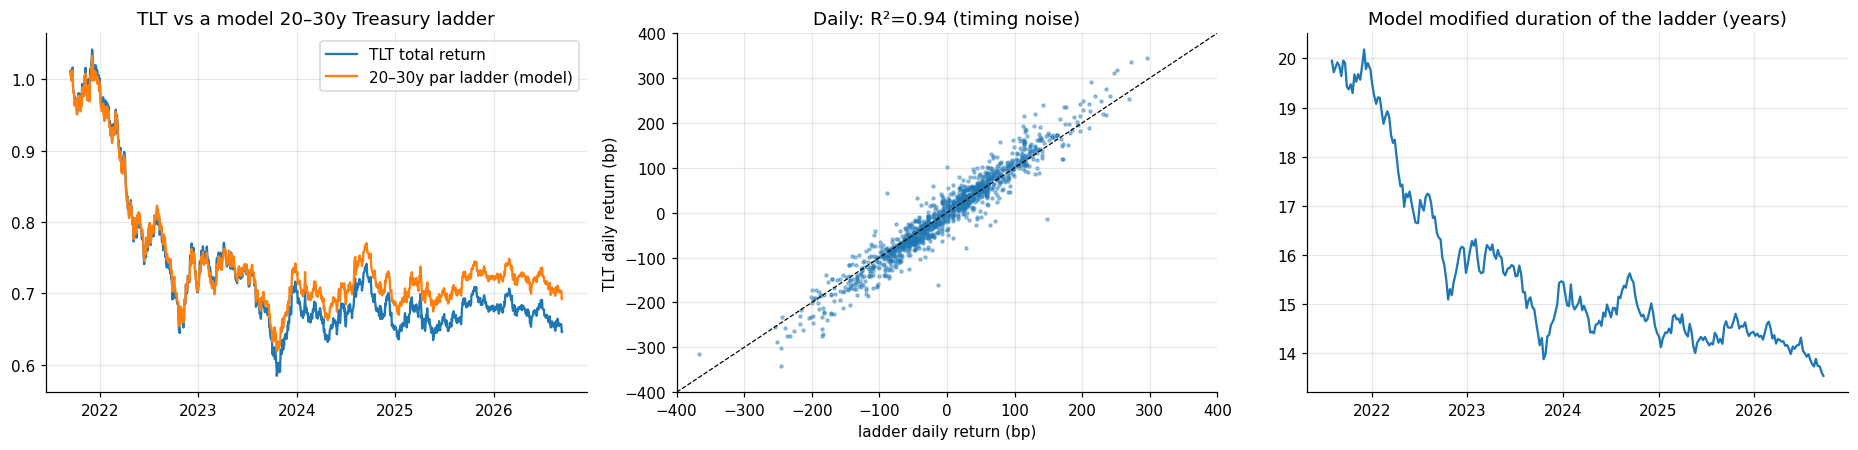

In [3]:
fig, axs = plt.subplots(1, 3, figsize=(17, 4.2))
cum = (1 + j).cumprod()
axs[0].plot(cum.index, cum.TLT, label="TLT total return"); axs[0].plot(cum.index, cum.ladder, label="20–30y par ladder (model)")
axs[0].set_title("TLT vs a model 20–30y Treasury ladder"); axs[0].legend()
axs[1].scatter(j.ladder * 1e4, j.TLT * 1e4, s=4, alpha=.4)
axs[1].plot([-400, 400], [-400, 400], "k--", lw=.8); axs[1].set_xlim(-400, 400); axs[1].set_ylim(-400, 400)
axs[1].set_xlabel("ladder daily return (bp)"); axs[1].set_ylabel("TLT daily return (bp)")
axs[1].set_title(f"Daily: R²={fit.rsquared:.2f} (timing noise)")
dur = [np.mean([mod_duration(Ymat.loc[d, M], M, Ymat.loc[d, M]) for M in MATS]) for d in Ymat.index[::5]]
axs[2].plot(Ymat.index[::5], dur); axs[2].set_title("Model modified duration of the ladder (years)")
plt.tight_layout(); plt.show()

TLT is almost a pure long-duration rate instrument. Its sensitivity is **~1.09× the par ladder's**, because TLT holds many *low-coupon*
bonds issued when rates were near zero, and a low-coupon bond has a longer duration than a par bond of the same maturity. With a ladder
duration of ~13–14 years, TLT's is roughly 15–16 years, so a 10 bp move in long yields is a ~1.5 % move in TLT. But the *daily* fit is visibly noisy, while the *weekly* one is much tighter. The noise isn't mispricing. It is the
**timing mismatch**: FRED's CMT yields are read off the market in the afternoon, TLT's close is at 16:00, and the model ladder
isn't the exact index. Any daily "premium/discount" built this way would mostly be measurement error. To see genuine
dislocations we need a fair value observed **at the same instant** as the ETF price, i.e. futures.

## 3. Futures-implied fair value
We build 5-minute bars for TLT (09:30–16:00 ET) and for the **front UB and ZB contracts** (the most active contract each day; we
work only with *intraday* returns and daily returns *within* a contract, so rolls never create jumps).

**Hedge ratio.** For each day $d$, regress TLT's 5-minute log returns on UB's (and ZB's) over the previous 20 sessions:
$r^{TLT}_t=\beta_d\, r^{UB}_t+\varepsilon_t$. This gives the *empirical* DV01 ratio (TLT vs UB duration), with no bond math.

**Dislocation.** Within day $d$, the cumulative hedged residual from the open
$$S_t=\sum_{u\le t}\big(r^{TLT}_u-\beta_d\,r^{UB}_u\big)$$
measures how far TLT has moved *relative to* the futures since 09:35. We divide it by its typical size (the RMS of $S$ over the
previous 20 sessions) to get a z-score. It is an intraday measure of the ETF's premium drift, free of the NAV-timing problem.

In [4]:
fut = treasury_futures_1m()
fut["ts_ny"] = fut.ts_event.dt.tz_convert("America/New_York").dt.tz_localize(None)
fut["root"] = fut.symbol.str.extract(r"^(UB|ZB|ZN)")[0]
fut["date"] = fut.ts_ny.dt.normalize()
fut = fut[(fut.ts_ny.dt.hour * 60 + fut.ts_ny.dt.minute).between(570, 959)]
front = fut.groupby(["root", "date", "symbol"]).volume.sum().reset_index().sort_values("volume").drop_duplicates(["root", "date"], keep="last")
fut = fut.merge(front[["root", "date", "symbol"]], on=["root", "date", "symbol"])

END_F = fut.date.max()
tlt_m = load_minute_bars(["TLT"], "2021-09-01", END_F)


def bars5(df, px="close", vol="volume"):
    d = df.set_index("ts_ny")
    o = d.groupby(pd.Grouper(freq="5min", label="right", closed="left")).agg(close=(px, "last"), volume=(vol, "sum"),
                                                                             n=(px, "size"))
    return o[o.n > 0]


T5 = bars5(tlt_m)
U5 = bars5(fut[fut.root == "UB"])
Z5 = bars5(fut[fut.root == "ZB"])
B = pd.concat({"TLT": T5.close, "UB": U5.close, "ZB": Z5.close, "TLTvol": T5.volume, "UBvol": U5.volume}, axis=1).dropna()
B = B[(B.index.hour * 60 + B.index.minute).isin(range(575, 961))]
B["date"] = B.index.normalize()
lr = np.log(B[["TLT", "UB", "ZB"]]).groupby(B.date).diff()        # intraday 5-min log returns (no overnight / roll jumps)
lr["date"] = B.date
lr = lr.dropna()
days = np.array(sorted(lr.date.unique()))
print(f"{len(B):,} synchronised 5-minute bars on {len(days)} days ({days[0].date()} → {days[-1].date()})")

72,917 synchronised 5-minute bars on 938 days (2021-09-13 → 2025-06-06)


,beta_UB,R2_UB,beta_ZB,R2_ZB
mean,0.9672,0.9512,1.2513,0.8569
std,0.0390,0.0245,0.1326,0.0267
min,0.8469,0.8591,0.9595,0.7353
max,1.0339,0.9839,1.5877,0.9202


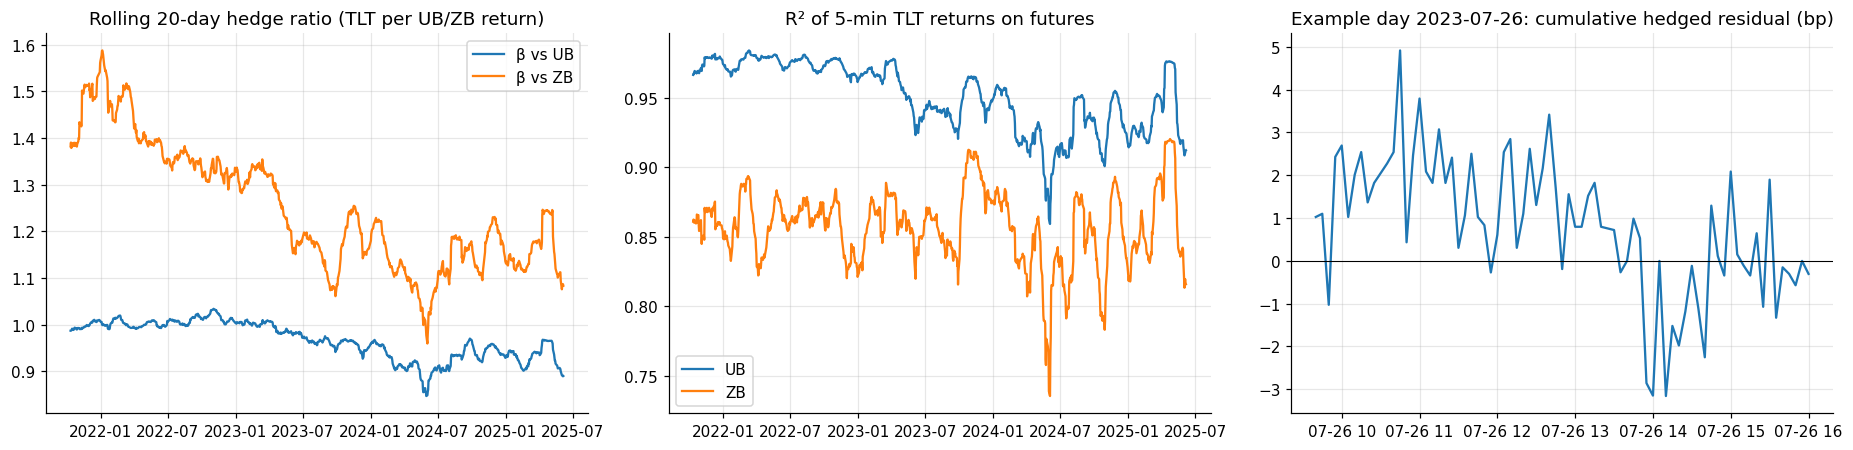

In [5]:
beta_ub, beta_zb, r2_ub, r2_zb = {}, {}, {}, {}
g = dict(tuple(lr.groupby("date")))
for i in range(20, len(days)):
    h = pd.concat([g[d] for d in days[i - 20:i]])
    for nm, bd, rd in (("UB", beta_ub, r2_ub), ("ZB", beta_zb, r2_zb)):
        x, y = h[nm].values, h.TLT.values
        b = (x @ y) / (x @ x); bd[days[i]] = b
        rd[days[i]] = 1 - np.sum((y - b * x) ** 2) / np.sum((y - y.mean()) ** 2)
betas = pd.DataFrame({"beta_UB": beta_ub, "R2_UB": r2_ub, "beta_ZB": beta_zb, "R2_ZB": r2_zb})
display(betas.describe().loc[["mean", "std", "min", "max"]])

lr = lr[lr.date.isin(betas.index)]
lr["beta"] = lr.date.map(betas.beta_UB)
lr["resid"] = lr.TLT - lr.beta * lr.UB
lr["S"] = lr.groupby("date").resid.cumsum()
# normalise by the dispersion of S itself over the previous 20 sessions (strictly past data)
s_sd = lr.groupby("date").S.apply(lambda x: np.sqrt(np.mean(x ** 2))).shift(1).rolling(20).mean()
lr["z"] = lr.S / lr.date.map(s_sd)
lr = lr.dropna(subset=["z"])

fig, axs = plt.subplots(1, 3, figsize=(17, 4.2))
axs[0].plot(betas.index, betas.beta_UB, label="β vs UB"); axs[0].plot(betas.index, betas.beta_ZB, label="β vs ZB")
axs[0].set_title("Rolling 20-day hedge ratio (TLT per UB/ZB return)"); axs[0].legend()
axs[1].plot(betas.index, betas.R2_UB, label="UB"); axs[1].plot(betas.index, betas.R2_ZB, label="ZB")
axs[1].set_title("R² of 5-min TLT returns on futures"); axs[1].legend()
d_ex = days[len(days) // 2]
ex = lr[lr.date == d_ex]
axs[2].plot(ex.index, ex.S * 1e4); axs[2].axhline(0, color="k", lw=.7)
axs[2].set_title(f"Example day {pd.Timestamp(d_ex).date()}: cumulative hedged residual (bp)")
plt.tight_layout(); plt.show()

UB explains most of TLT's 5-minute variance (R² in the table above); ZB is slightly worse because its deliverable basket is
shorter than TLT's holdings. The hedge ratio moves with the relative duration of TLT and UB's cheapest-to-deliver bond.

## 4. Liquidity, and how it drives dislocations
Liquidity has several dimensions (Kyle 1985; Amihud 2002). We measure each daily:

| Dimension | Proxy |
|---|---|
| tightness | TLT effective-spread estimate (Massive `spread_est`) |
| depth / price impact | Amihud illiquidity = $|r|$ / dollar volume (per \$100 m traded) |
| activity | TLT dollar volume, UB contract volume |
| stress | 20-day realised volatility of UB returns (a MOVE-index proxy) |

Then we ask whether the *size of dislocations* (intraday dispersion of the hedged residual $S_t$) and their *persistence*
(half-life) depend on these conditions.

In [6]:
feat = load_intraday_features(["TLT"], "2021-09-01", END_F, ["spread_est", "dollar_vol_reg", "rv_5m"]).set_index("date")
ubd = fut[fut.root == "UB"].groupby("date").agg(ub_vol=("volume", "sum"))
dd = pd.DataFrame({"disp_bp": lr.groupby("date").S.apply(lambda s: s.abs().mean()) * 1e4,
                   "range_bp": lr.groupby("date").S.apply(lambda s: s.max() - s.min()) * 1e4})
dd = dd.join(feat[["spread_est", "dollar_vol_reg"]]).join(ubd)
ub_daily = lr.groupby("date").UB.sum()
dd["ub_rv20"] = ub_daily.rolling(20).std().reindex(dd.index) * np.sqrt(252)
tlt_ret = tlt_d.ret.reindex(dd.index)
dd["amihud"] = (tlt_ret.abs() / (dd.dollar_vol_reg / 1e8)).rolling(5).mean()
dd["spread_bp"] = dd.spread_est * 1e4
dd = dd.dropna()

X = pd.DataFrame({"log spread": np.log(dd.spread_bp), "log Amihud": np.log(dd.amihud), "log $vol": np.log(dd.dollar_vol_reg),
                  "log UB vol": np.log(dd.ub_vol), "log UB rv20": np.log(dd.ub_rv20)})
Xs = (X - X.mean()) / X.std()
reg = sm.OLS(np.log(dd.disp_bp), sm.add_constant(Xs)).fit(cov_type="HAC", cov_kwds={"maxlags": 5})
print("log(mean |intraday dislocation|) on standardised liquidity proxies (Newey–West t-stats)")
display(pd.DataFrame({"coef": reg.params, "t": reg.tvalues}).round(3))
print(f"R² = {reg.rsquared:.2f}")

# half-life of the 5-minute residual process by liquidity tercile: AR(1) on S within day
dd["liq_tercile"] = pd.qcut(dd.spread_bp.rank(method="first"), 3, labels=["tight spread", "medium", "wide spread"])
hl = {}
for lab, grp in dd.groupby("liq_tercile"):
    sub = lr[lr.date.isin(grp.index)]
    s0 = sub.groupby("date").S.shift(1); s1 = sub.S
    ok = s0.notna()
    phi = sm.OLS(s1[ok].values, s0[ok].values).fit().params[0]
    hl[lab] = {"AR(1) φ (5-min)": phi, "half-life (minutes)": 5 * np.log(0.5) / np.log(phi) if 0 < phi < 1 else np.inf,
               "mean |S| (bp)": grp.disp_bp.mean(), "mean spread (bp)": grp.spread_bp.mean()}
pd.DataFrame(hl).T

log(mean |intraday dislocation|) on standardised liquidity proxies (Newey–West t-stats)


,coef,t
const,1.0060,43.0120
log spread,0.0270,1.0560
log Amihud,0.0820,3.3520
log $vol,0.0870,2.8010
log UB vol,0.1070,2.7610
log UB rv20,0.0460,1.5340


R² = 0.09


,AR(1) φ (5-min),half-life (minutes),mean |S| (bp),mean spread (bp)
tight spread,0.9472,63.8339,3.0979,0.8925
medium,0.9400,55.9850,3.2483,1.0546
wide spread,0.9444,60.6020,3.4234,1.2817


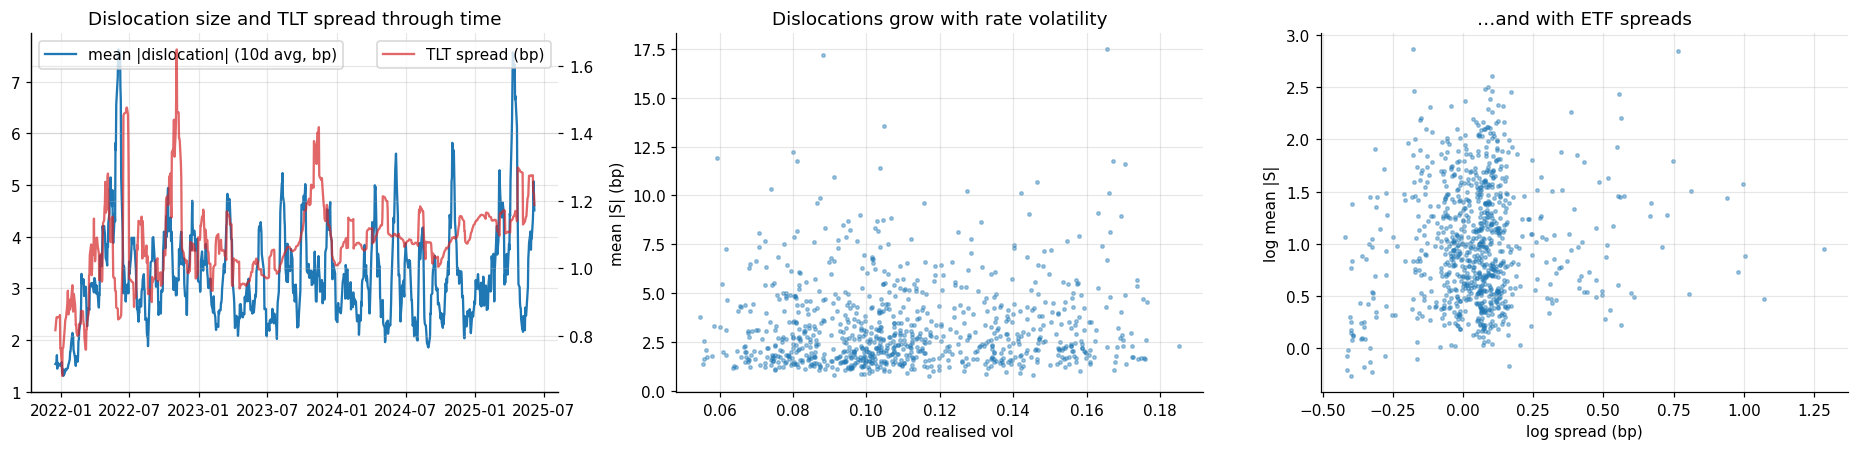

In [7]:
fig, axs = plt.subplots(1, 3, figsize=(17, 4.2))
axs[0].plot(dd.index, dd.disp_bp.rolling(10).mean(), label="mean |dislocation| (10d avg, bp)")
ax2 = axs[0].twinx(); ax2.plot(dd.index, dd.spread_bp.rolling(10).mean(), color="tab:red", alpha=.7, label="TLT spread (bp)")
axs[0].set_title("Dislocation size and TLT spread through time"); axs[0].legend(loc="upper left"); ax2.legend(loc="upper right")
axs[1].scatter(dd.ub_rv20, dd.disp_bp, s=5, alpha=.4); axs[1].set_xlabel("UB 20d realised vol"); axs[1].set_ylabel("mean |S| (bp)")
axs[1].set_title("Dislocations grow with rate volatility")
axs[2].scatter(np.log(dd.spread_bp), np.log(dd.disp_bp), s=5, alpha=.4); axs[2].set_xlabel("log spread (bp)"); axs[2].set_ylabel("log mean |S|")
axs[2].set_title("…and with ETF spreads")
plt.tight_layout(); plt.show()

**What the liquidity analysis shows.** Check the signs and t-stats above:
* The table and scatter plots above relate the daily size of intraday dislocations to liquidity proxies. The interpretation is
  summarised after the strategy results in §5, so that both pieces of evidence are read together.

## 5. A statistical-arbitrage strategy with liquidity constraints
**Signal.** At each 5-minute bar, if $z_t<-z_{in}$ (TLT cheap vs futures) buy TLT and sell $\beta$ UB, if $z_t>z_{in}$ do the reverse;
exit when $|z_t|<z_{out}$, and always go flat by 15:55 (no overnight risk, no roll). Decisions use bar $t$'s close, and trades
execute at bar $t+1$'s close (one-bar latency).

**Costs.** TLT: half the estimated spread (previous day's `spread_est`) per side. UB: half a tick ($\tfrac1{64}$ of a point) per side,
≈1.3 bp at a price of ~120.

**Liquidity constraints.**
1. *Participation cap*: position ≤ 5 % of the TLT volume traded in the entry bar (in \$), and at most \$20 m.
2. *Spread filter*: don't open positions on days when yesterday's TLT spread is in its top 20 % (trailing 60 days). Dislocations are
   larger then, but so are costs and the risk that they keep widening (the "limits to arbitrage", Shleifer–Vishny 1997).
3. *Volatility-scaled entry*: the z-score already normalises by trailing residual volatility.

In [8]:
def run_strategy(z_in=2.0, z_out=0.5, use_filters=True, cap_part=0.05, cap_notional=20e6, fees=True, tlt_spread_mult=1.0):
    df = lr[["TLT", "UB", "beta", "z", "date"]].copy()
    df["tltvol_usd"] = (B.TLTvol * B.TLT).reindex(df.index)
    sp = dd.spread_bp.reindex(df.date.unique())
    sp_prev = sp.shift(1)
    sp_thr = sp.shift(1).rolling(60, min_periods=20).quantile(0.8)
    df["spread_prev_bp"] = df.date.map(sp_prev)
    df["blocked"] = df.date.map(sp_prev > sp_thr).fillna(False) if use_filters else False
    minute = df.index.hour * 60 + df.index.minute
    pos = np.zeros(len(df)); notional = np.zeros(len(df))
    cur, cur_n = 0, 0.0
    zv, blk, dates_, vol_usd = df.z.values, df.blocked.values, df.date.values, df.tltvol_usd.values
    for i in range(len(df)):
        last_bar = minute[i] >= 955 or (i + 1 < len(df) and dates_[i + 1] != dates_[i])
        if cur != 0 and (abs(zv[i]) < z_out or np.sign(zv[i]) == cur or last_bar):
            cur, cur_n = 0, 0.0
        if cur == 0 and not last_bar and not blk[i] and abs(zv[i]) > z_in:
            cur = -int(np.sign(zv[i]))
            cur_n = min(cap_notional, cap_part * vol_usd[i]) if use_filters else cap_notional
        pos[i], notional[i] = cur, cur_n
    df["pos"] = pd.Series(pos, index=df.index).groupby(df.date).shift(1).fillna(0)       # one-bar latency
    df["notional"] = pd.Series(notional, index=df.index).groupby(df.date).shift(1).fillna(0)
    hedged = df.TLT - df.beta * df.UB
    df["gross"] = df.pos * df.notional * hedged
    trade = (df.pos * df.notional).groupby(df.date).diff().fillna(df.pos * df.notional).abs()
    cost_bp = (tlt_spread_mult * df.spread_prev_bp.fillna(df.spread_prev_bp.median()) / 2 + 1.3 * df.beta) / 1e4
    df["cost"] = trade * cost_bp if fees else 0.0
    df["net"] = df.gross - df.cost
    daily = df.groupby("date")[["gross", "cost", "net"]].sum()
    n_trades = int(((df.pos != 0) & (df.pos.groupby(df.date).shift(1).fillna(0) == 0)).sum())
    avg_n = df.loc[df.pos != 0, "notional"].mean()
    return daily, n_trades, avg_n


def summarise(daily, n_trades, avg_n, cap=20e6):
    net = daily.net / cap
    return {"trades": n_trades, "avg position ($m)": avg_n / 1e6, "gross P&L ($k)": daily.gross.sum() / 1e3,
            "costs ($k)": daily.cost.sum() / 1e3, "net P&L ($k)": daily.net.sum() / 1e3,
            "gross per trade (bp)": daily.gross.sum() / max(n_trades, 1) / avg_n * 1e4,
            "net Sharpe (daily)": net.mean() / net.std() * np.sqrt(252) if net.std() > 0 else np.nan,
            "hit rate (days)": (daily.net[daily.net != 0] > 0).mean()}


variants = {
    "no costs, no liquidity rules": run_strategy(use_filters=False, fees=False),
    "costs, no liquidity rules": run_strategy(use_filters=False, fees=True),
    "costs + liquidity rules": run_strategy(use_filters=True, fees=True),
    "costs + liquidity rules, z_in=3": run_strategy(z_in=3.0, use_filters=True, fees=True),
    "passive TLT fills (optimistic), liquidity rules": run_strategy(use_filters=True, fees=True, tlt_spread_mult=0.0),
}
summ = pd.DataFrame({k: summarise(*v) for k, v in variants.items()}).T
summ

,trades,avg position ($m),gross P&L ($k),costs ($k),net P&L ($k),gross per trade (bp),net Sharpe (daily),hit rate (days)
"no costs, no liquidity rules",434.0000,20.0000,"1,732.6247",0.0000,"1,732.6247",1.9961,4.5465,0.6959
"costs, no liquidity rules",434.0000,20.0000,"1,732.6247","3,106.0289","-1,373.4042",1.9961,-3.9744,0.3686
costs + liquidity rules,294.0000,2.3211,66.4127,222.9062,-156.4935,0.9732,-2.0146,0.3609
"costs + liquidity rules, z_in=3",86.0000,2.5664,7.5478,69.0825,-61.5347,0.3420,-1.7633,0.1977
"passive TLT fills (optimistic), liquidity rules",294.0000,2.3211,66.4127,159.7304,-93.3177,0.9732,-1.2983,0.4586


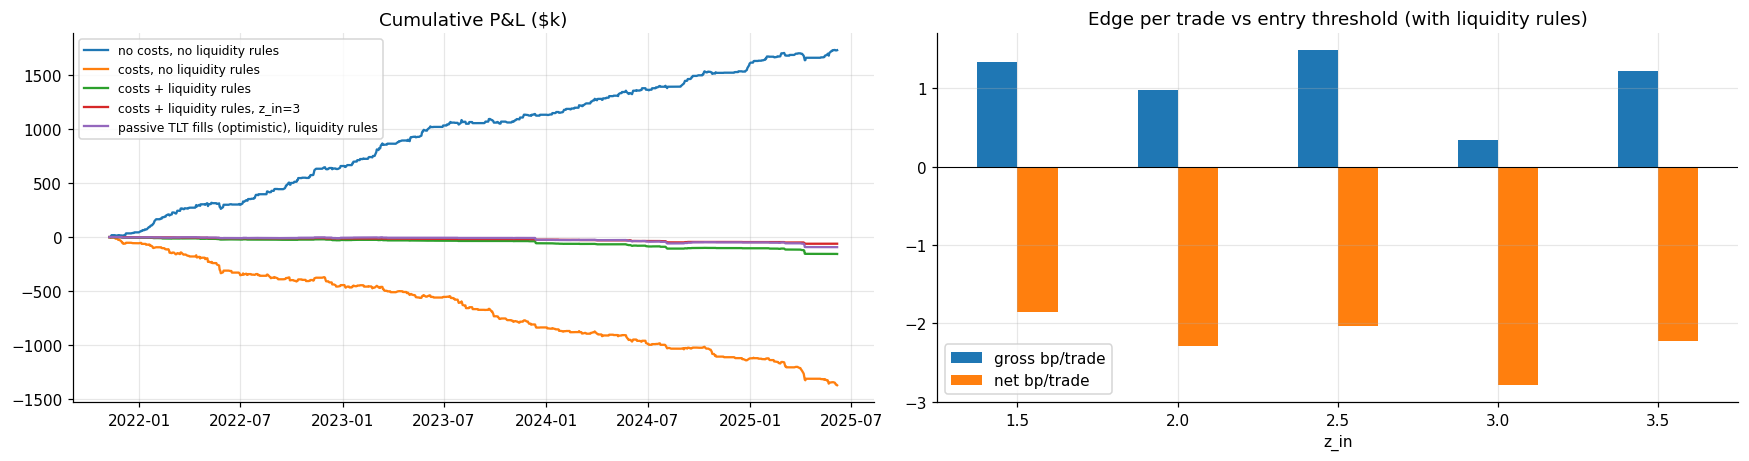

,gross bp/trade,net bp/trade,trades
z_in,,,
1.5000,1.3297,-1.8510,599
2.0000,0.9732,-2.2933,294
2.5000,1.4860,-2.0289,148
3.0000,0.3420,-2.7880,86
3.5000,1.2130,-2.2252,47


In [9]:
fig, axs = plt.subplots(1, 2, figsize=(16, 4.3))
for k, (daily, _, _) in variants.items():
    axs[0].plot(daily.net.cumsum() / 1e3, label=k)
axs[0].set_title("Cumulative P&L ($k)"); axs[0].legend(fontsize=8)
grid = []
for zi in [1.5, 2.0, 2.5, 3.0, 3.5]:
    dly, n, a = run_strategy(z_in=zi, use_filters=True, fees=True)
    dly0, n0, a0 = run_strategy(z_in=zi, use_filters=True, fees=False)
    grid.append({"z_in": zi, "gross bp/trade": dly0.gross.sum() / max(n0, 1) / a0 * 1e4,
                 "net bp/trade": dly.net.sum() / max(n, 1) / a * 1e4, "trades": n})
grid = pd.DataFrame(grid).set_index("z_in")
grid[["gross bp/trade", "net bp/trade"]].plot.bar(ax=axs[1]); axs[1].axhline(0, color="k", lw=.7)
axs[1].set_title("Edge per trade vs entry threshold (with liquidity rules)"); axs[1].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()
grid

**Interpretation.**
* **The gross edge is real but tiny.** Fading |z| > 2 captures ~1–2 bp per trade before costs, with a very high gross Sharpe:
  the hedged residual does mean-revert within the day.
* **Costs are larger than the edge.** A round trip costs ≈ 2 × (TLT half-spread ≈ 0.5 bp + UB half-tick ≈ 1.3 bp × β) ≈ 3.5 bp,
  roughly twice the average captured move. Every cost-paying variant loses money, whatever the entry threshold. Higher
  thresholds don't produce reliably larger reversions at 5-minute resolution; the edge per trade is noisy and never covers costs.
* **Liquidity rules limit the damage.** The participation cap shrinks the average position from \$20 m to a few \$m (TLT's 5-minute
  volume is the binding constraint), and the spread filter skips the most expensive days. Losses fall by an order of magnitude, but
  rules can't create an edge that isn't there.
* **Who earns the rent?** Even the optimistic "passive TLT" variant (it assumes every TLT order fills at no spread cost, i.e. we are the
  market maker, and it ignores adverse selection) still loses. The futures leg alone costs ≈ 2.5 bp per round trip, more than the
  ~1–2 bp captured move. To profit, you'd have to be passive on *both* legs, or trade at a much finer time scale where the reversion is
  larger relative to costs. This is the economic reality of ETF arbitrage: the dislocation is the compensation that ETF market makers and APs
  earn for providing liquidity. An outsider crossing spreads at bar frequency pays it to them.

**What the liquidity regression says (§4).** Dislocation size is only weakly predictable from daily liquidity proxies (R² ≈ 0.1). The
significant predictors are **price impact (Amihud)** and **trading activity** (TLT dollar volume, UB volume); spreads and rate
volatility add little once those are included. Active, high-impact days are the days when large flows hit the ETF faster than hedgers
can offset them in futures, which is exactly the liquidity-mismatch channel. The dislocations are persistent within the day (5-minute
AR(1) ≈ 0.94, a half-life of about an hour), and the persistence barely differs across spread terciles in this calm-ish sample.

## 6. Strengths, weaknesses, extensions
**Strengths**
* Fair value is observed *at the same instant* as the ETF price, which removes the NAV-timing artefact that contaminates naive
  premium/discount studies.
* The hedge ratio is estimated from data (an empirical DV01 ratio), with no bond-by-bond pricing needed.
* Liquidity enters twice: as an explanatory variable for dislocations, and as hard constraints on the strategy.

**Weaknesses**
* **No official NAV / iNAV or AP creation-redemption data**, so we can't observe the true premium or the arbitrage band itself.
* The futures are a proxy for the bonds, not the basket. **Basis risk** (the CTD switch, the futures/cash basis, repo specialness) sits in
  the residual. A real ETF-vs-cash-bond arbitrage would also trade the bonds and face their much wider spreads.
* Spread estimates are *estimates* from bar data, not quoted NBBO spreads. Market impact beyond the half-spread is ignored (the
  participation cap keeps it small).
* The period (2021–2025) contains rate volatility but no March-2020-style liquidity crisis, when discounts reached several percent.
* Bars at 5 minutes are slow relative to the measured half-life, so real harvesting needs quote-level data (Databento TBBO / MBP for
  futures; NBBO for the ETF).

**Extensions**
* Add the ETF's daily share-creation/redemption data (shares-outstanding changes) to see when APs act.
* Model the dislocation as an OU process with liquidity-dependent mean-reversion speed and volatility, and derive optimal bands
  (Bertram 2010) that account for costs.
* Cross-section: IEF vs ZN, SHY vs ZT, LQD/HYG vs CDX, where credit-ETF discounts are much larger and more liquidity-driven.

**References.** Pan & Zeng, "ETF arbitrage under liquidity mismatch" (2019); Haddad, Moreira & Muir, "When selling becomes viral:
disruptions in debt markets in the COVID-19 crisis" (2021); Shleifer & Vishny, "The limits of arbitrage" (1997); Amihud (2002);
Bertram, "Analytic solutions for optimal statistical arbitrage trading" (2010).